In [ ]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
import preparations as prep # dataset loading and definitions
import helper as hlp # helper functions for plotting and image processing
import importlib
importlib.reload(hlp)
importlib.reload(prep)

<module 'helper' from 'c:\\Users\\Thoma\\Downloads\\Python\\Github\\Covid-19_detection\\notebooks\\helper.py'>

In [ ]:
# Libraries
import os
import pandas as pd
import numpy as np

# Imports for model building
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reporting
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imblearn.metrics import classification_report_imbalanced

# Imports for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
# List available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ TensorFlow is using a GPU:")
    for gpu in gpus:
        print("  -", gpu)
else:
    print("❌ No GPU detected. TensorFlow is using the CPU.")

✅ TensorFlow is using a GPU:
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### First try with Transfer Learning

##### Dataset loading and preprocessing

In [ ]:
# Load the original dataset, if not done yet
prep.download_and_move_dataset()

# Read in the images
train_ds, val_ds, class_names = hlp.read_only_xray_images()

Created empty directory: c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_653094453
Made directory: c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_653094453\COVID\
Moved c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\COVID-19_Radiography_Dataset\COVID\masks to c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_653094453\COVID\masks
Made directory: c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_653094453\Lung_Opacity\
Moved c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\COVID-19_Radiography_Dataset\Lung_Opacity\masks to c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_653094453\Lung_Opacity\masks
Made directory: c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_653094453\Normal\
Moved c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\COVID-19_Radiography_Dataset\Normal\masks to c:\Users\Thoma\Downloads\Python\Github\Covid-19_detection\tmp_653094453\Normal\masks
Made directory: c:

In [4]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy())

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy())

# Let's check compatible input format for VGG16
for images, labels in train_ds.take(1):
    print('Batch shape:', images.shape, labels.shape)
    # Show some sample image shapes and according labels (should be shuffled!)
    for image, label in zip(images.numpy(),labels.numpy()):
        print(image.shape, label)

Number of batch in train_ds: 530
Number of batch in val_ds: 133
Batch shape: (32, 224, 224, 3) (32,)
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 3
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 0
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 3
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 0


In [5]:
# We have imbalanced data, hence let's calculate class_weights to give it the model
from collections import Counter

# Count occurrences of each class
class_counts = Counter()
total_count = 0
for images, labels in train_ds:
    for label in labels.numpy():  # Convert tensor to numpy
        class_counts[label] += 1
        total_count += 1

# Convert label indices to class names
class_counts_named = {class_names[idx]: count for idx, count in class_counts.items()}
print("Class Counts:", class_counts_named)

class_weights_dict = { class_label: total_count / (len(class_counts) * class_counts[class_label])
                 for class_label, class_count in class_counts.items() }
print('Class Weights:', class_weights_dict)

Class Counts: {'Viral Pneumonia': 1048, 'Lung_Opacity': 4847, 'Normal': 8134, 'COVID': 2903}
Class Weights: {np.int32(3): 4.03912213740458, np.int32(1): 0.8733237053847741, np.int32(2): 0.5204081632653061, np.int32(0): 1.4581467447468137}


In [6]:
# Preprocessing for pretrained models in the same way
# the preprocessor comes with the pretrained model library
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

#### Try with VGG16 (imagenet pretrained)

In [ ]:
# Make sure, the models folder exists
if not os.path.exists(os.path.join('..', 'models')):
    os.makedirs(os.path.join('..', 'models'))

# This model name for saving and loading
model_name = os.path.join('..', 'models', '3a_vgg16_dense512.keras')

In [8]:
# Imports for using a pre-trained model
from tensorflow.keras.applications.vgg16 import VGG16

# VGG16 model
base_model = VGG16(weights='imagenet', include_top=False)

# Freeze the layers of VGG16
base_model.trainable = False

# Model creation using the Functional API
inputs = Input(shape=(224, 224, 3))

# Apply augmentations
#x = RandomRotation(0.1)(inputs)
#x = RandomTranslation(height_factor=0.1, width_factor=0.1)(x)
#x = RandomZoom(0.1)(x)
#x = RandomFlip("horizontal")(x)

# Build the model
x = base_model(inputs)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(rate=0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(rate=0.2)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

vgg16 = Model(inputs=inputs, outputs=outputs)

In [ ]:
# Applied Callbacks
early_stopping = EarlyStopping(
                                patience=5, # Wait for 5 epochs before applying
                                min_delta=0.01, # If the loss function doesn't change by 1% after 3 epochs, either up or down, we stop
                                verbose=1, # Display the epoch at which training stops
                                mode='min',
                                monitor='val_loss')

# A learning rate reduction callback to reduce the learning rate when the validation loss stagnates
reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # If val_loss stagnates for 3 consecutive epochs based on the min_delta value
                                    min_delta=0.01,
                                    factor=0.1,  # Reduce the learning rate by a factor of 0.1
                                    cooldown=3,  # Wait 3 epochs before retrying
                                    verbose=1)

In [ ]:
# Compile with first idea of appropriate parameters
vgg16.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Print how it looks like
vgg16.summary()

# Convert summary to DataFrame and display it (for copy and paste purposes)
df_summary = hlp.model_summary_to_df(vgg16)
display(df_summary)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,766,852 (60.15 MB)

 Trainable params: 1,052,164 (4.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

,Layer Name (type),Output Shape,Param Count
0,input_layer_1 (InputLayer),"(None, 224, 224, 3)",0
1,vgg16 (Functional),"(None, 7, 7, 512)","14,714,688"
2,global_average_pooling2d,"(None, 512)",0
3,(GlobalAveragePooling2D),,
4,dense (Dense),"(None, 1024)","525,312"
5,dropout (Dropout),"(None, 1024)",0
6,dense_1 (Dense),"(None, 512)","524,800"
7,dropout_1 (Dropout),"(None, 512)",0
8,dense_2 (Dense),"(None, 4)","2,052"


In [ ]:
# Train it with the entire dataset (takes very long!)
history_model = vgg16.fit(train_ds,
                          epochs=25,
                          validation_data=val_ds,
                          class_weight=class_weights_dict,
                          callbacks=[early_stopping, reduce_learning_rate]))

Epoch 1/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 966s 2s/step - accuracy: 0.7240 - loss: 0.8676 - val_accuracy: 0.8731 - val_loss: 0.3499
Epoch 2/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 987s 2s/step - accuracy: 0.8434 - loss: 0.3520 - val_accuracy: 0.8909 - val_loss: 0.3142
Epoch 3/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 967s 2s/step - accuracy: 0.8664 - loss: 0.2813 - val_accuracy: 0.8670 - val_loss: 0.3535
Epoch 4/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 1004s 2s/step - accuracy: 0.8654 - loss: 0.2914 - val_accuracy: 0.8932 - val_loss: 0.2853
Epoch 5/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 1002s 2s/step - accuracy: 0.8886 - loss: 0.2259 - val_accuracy: 0.8859 - val_loss: 0.3055
Epoch 6/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 1003s 2s/step - accuracy: 0.8984 - loss: 0.2009 - val_accuracy: 0.8953 - val_loss: 0.2897
Epoch 7/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 1006s 2s/step - accuracy: 0.8928 - loss: 0.2195 - val_accuracy: 0.8972 - val_loss: 0.2908
Epoch 8/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 1003s 2s/step - accuracy: 0.9053 - loss: 0.1873 - val

In [12]:
# Save the model for potential later use
vgg16.save(model_name)

##### Evalution

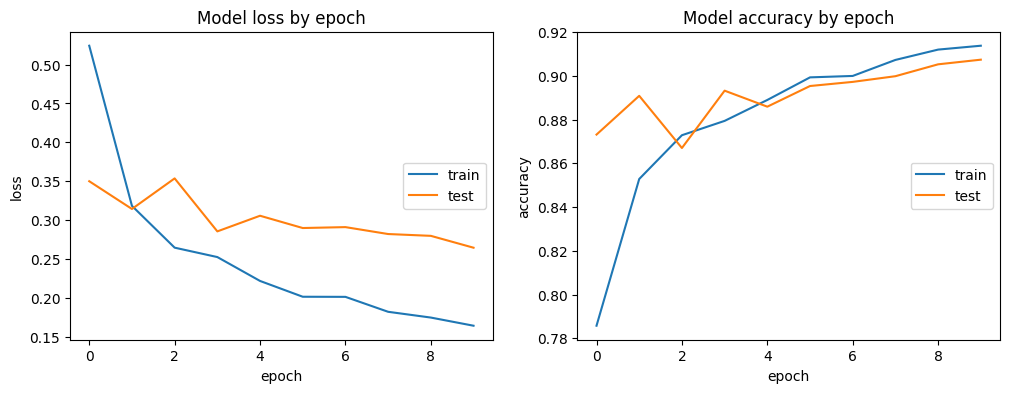

In [ ]:
hlp.plot_learning_curve(history_model)

> We can see, that our model accuracy stagnates at appr. 70%
> It seems, that we cannot improve here much.

In [14]:
from tensorflow import keras
vgg16 = keras.models.load_model(model_name)

In [ ]:
#y_true, y_pred = get_predictions_and_labels(vgg16, val_ds.take(8)) # for a quick result
y_true, y_pred = hlp.get_predictions_and_labels(vgg16, val_ds)

,pre,rec,spe,f1,geo,iba,sup
COVID,0.934286,0.917251,0.986932,0.925690,0.951454,0.898956,713.000000
Lung_Opacity,0.858091,0.887554,0.944263,0.872574,0.915469,0.833332,1165.000000
Normal,0.924752,0.907677,0.930115,0.916135,0.918828,0.842350,2058.000000
Viral Pneumonia,0.925325,0.959596,0.994157,0.942149,0.976723,0.950692,297.000000
avg_pre,0.908052,0.908052,0.908052,0.908052,0.908052,0.908052,0.908052
avg_rec,0.907394,0.907394,0.907394,0.907394,0.907394,0.907394,0.907394
avg_spe,0.948072,0.948072,0.948072,0.948072,0.948072,0.948072,0.948072
avg_f1,0.907581,0.907581,0.907581,0.907581,0.907581,0.907581,0.907581
avg_geo,0.927461,0.927461,0.927461,0.927461,0.927461,0.927461,0.927461
avg_iba,0.857004,0.857004,0.857004,0.857004,0.857004,0.857004,0.857004


Predicted,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,654,19,37,3
Lung_Opacity,27,1034,103,1
Normal,19,152,1868,19
Viral Pneumonia,0,0,12,285


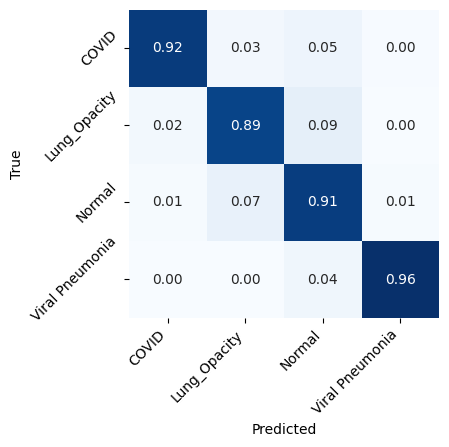

{'crosstab': Predicted        COVID  Lung_Opacity  Normal  Viral Pneumonia
 COVID              654            19      37                3
 Lung_Opacity        27          1034     103                1
 Normal              19           152    1868               19
 Viral Pneumonia      0             0      12              285,
 'classification_report':                          pre          rec          spe           f1  \
 COVID               0.934286     0.917251     0.986932     0.925690   
 Lung_Opacity        0.858091     0.887554     0.944263     0.872574   
 Normal              0.924752     0.907677     0.930115     0.916135   
 Viral Pneumonia     0.925325     0.959596     0.994157     0.942149   
 avg_pre             0.908052     0.908052     0.908052     0.908052   
 avg_rec             0.907394     0.907394     0.907394     0.907394   
 avg_spe             0.948072     0.948072     0.948072     0.948072   
 avg_f1              0.907581     0.907581     0.907581     0.907581   

In [ ]:
hlp.report_model_performance(y_true, y_pred, class_names)

# Conclusion: Our model predicts the 4 classes already pretty well